# Krok 8 — Churn Prediction

| Položka | Hodnota |
|---------|---------|
| **Projekt** | CLV Predikce 2025 |
| **Krok** | 8 / 8 |
| **Datum** | 2025-06-01 |
| **Autor** | Datový analytik |
| **Verze** | 1.0 |

**Cíl notebooku:**  
Predikovat, který zákazník odchurňuje — tedy přestane nakupovat. Natrénovat logistickou  
regresi jako baseline a XGBoost jako hlavní model (s GridSearchCV). Výstup zkombinovat  
s CLV segmenty z Kroku 7 do akční matice: každý zákazník dostane jak riziko churnu,  
tak predikovaný CLV → business tím získá prioritizaci pro retention kampaně.

---
### Definice churnu a metodická rozhodnutí

**Churn je definován takto:**  
Zákazník nakoupil alespoň jednou v roce 2022 nebo 2023 (byl aktivní),  
ale **nenakoupil ani jednou v roce 2024** → `is_churned = 1`.

**Proč tato definice, ne absence v roce 2025:**  
- Rok 2025 je target pro CLV model — nesmíme ho použít jako definici churnu pro stejný model  
- Definice přes rok 2024 je čistá: máme plná data, žádné budoucí informace  
- Zákazníci, kteří nikdy nebyli aktivní (jen 2024 nebo jen 2025), jsou vyloučeni —  
  churn predikuje odchod stávajících zákazníků, ne absenci nových

**Features jsou počítány výhradně z let 2022–2023** (trénovací okno pro churn),  
aby model predikoval na základě dat předcházejících referenčnímu roku 2024.

**Validace:** Data z roku 2025 použijeme na konci jako nezávislou validaci —  
ověříme, zda zákazníci s vysokým rizikem churnu skutečně nenakoupili ani v 2025.


## 2. Imports & Setup

In [2]:
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
import seaborn as sns
import shap
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
)
from sklearn.model_selection import (
    GridSearchCV,
    StratifiedKFold,
    cross_val_score,
    train_test_split,
)
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier

warnings.filterwarnings("ignore")

RANDOM_STATE    = 42
TEST_SIZE       = 0.2
CV_FOLDS        = 5
WINSOR_QUANTILE = 0.99
REFERENCE_DATE  = pd.Timestamp("2023-12-31")   # konec trénovacího okna pro churn

INPUT_DIR  = Path("outputs")
OUTPUT_DIR = Path("outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 120
plt.rcParams["font.size"] = 11

print("Prostředí inicializováno.")


Prostředí inicializováno.


## 3. Načtení dat

In [3]:
try:
    df_orders   = pd.read_csv(INPUT_DIR / "step_01_orders.csv",   parse_dates=["order_date"])
    df_account  = pd.read_csv(INPUT_DIR / "step_01_account.csv",  parse_dates=["customer_since"])
    df_activity = pd.read_csv(INPUT_DIR / "step_01_activity.csv", parse_dates=["last_login_date"])
    df_clv_seg  = pd.read_csv(INPUT_DIR / "step_07_clv_segments.csv")
    print("✅ Vstupní soubory načteny.")
except FileNotFoundError as e:
    raise FileNotFoundError(f"Výstup předchozího kroku nenalezen: {e}")

df_orders["year"] = df_orders["order_date"].dt.year
df_completed = df_orders[df_orders["order_status"] == "Completed"].copy()

print(f"  Orders (completed): {len(df_completed):,}")
print(f"  Accounts:           {len(df_account):,}")


✅ Vstupní soubory načteny.
  Orders (completed): 9,303
  Accounts:           1,200


## 4. Definice cílové skupiny a churn targetu

In [4]:
# Zákazníci aktivní v 2022 nebo 2023 — cílová skupina pro churn predikci
ids_active_22_23 = set(
    df_completed[df_completed["year"].isin([2022, 2023])]["account_external_id"]
)

# Z nich — kdo nekoupil v 2024? → churned
ids_active_2024 = set(df_completed[df_completed["year"] == 2024]["account_external_id"])
ids_churned     = ids_active_22_23 - ids_active_2024
ids_retained    = ids_active_22_23 & ids_active_2024

# Validační množina: aktivita v 2025
ids_active_2025 = set(df_completed[df_completed["year"] == 2025]["account_external_id"])

model_ids   = sorted(ids_active_22_23)
churn_rate  = len(ids_churned) / len(ids_active_22_23)

print(f"Cílová skupina (aktivní v 2022 nebo 2023):  {len(ids_active_22_23):,}")
print(f"  Retained (nakoupili i v 2024):            {len(ids_retained):,} ({len(ids_retained)/len(ids_active_22_23):.1%})")
print(f"  Churned  (nenakoupili v 2024):            {len(ids_churned):,} ({churn_rate:.1%})")
print()
print(f"Validace — z churned zákazníků se vrátilo v 2025: "
      f"{len(ids_churned & ids_active_2025)} ({len(ids_churned & ids_active_2025)/len(ids_churned):.1%})")


Cílová skupina (aktivní v 2022 nebo 2023):  837
  Retained (nakoupili i v 2024):            476 (56.9%)
  Churned  (nenakoupili v 2024):            361 (43.1%)

Validace — z churned zákazníků se vrátilo v 2025: 12 (3.3%)


## 5. Feature Engineering pro churn model

In [5]:
# Trénovací okno: pouze Completed objednávky z let 2022–2023
df_train_w = df_completed[df_completed["year"].isin([2022, 2023])].copy()

# --- RFM z let 2022–2023 ---
recency = (
    df_train_w.groupby("account_external_id")["order_date"]
    .max()
    .apply(lambda d: (REFERENCE_DATE - d).days)
    .rename("recency_days")
)
frequency  = df_train_w.groupby("account_external_id").size().rename("frequency")
mon_total  = df_train_w.groupby("account_external_id")["order_value"].sum().rename("monetary_total")
mon_avg    = df_train_w.groupby("account_external_id")["order_value"].mean().rename("monetary_avg")
mon_std    = (df_train_w.groupby("account_external_id")["order_value"]
              .std().fillna(0).rename("monetary_std"))
disc_avg   = df_train_w.groupby("account_external_id")["discount_pct"].mean().rename("avg_discount_pct")
cat_div    = (df_train_w.groupby("account_external_id")["product_category"]
              .nunique().rename("category_diversity"))

# --- Roční trendy ---
spend_2022 = (df_train_w[df_train_w["year"] == 2022]
              .groupby("account_external_id")["order_value"].sum()
              .reindex(model_ids, fill_value=0).rename("spend_2022"))
spend_2023 = (df_train_w[df_train_w["year"] == 2023]
              .groupby("account_external_id")["order_value"].sum()
              .reindex(model_ids, fill_value=0).rename("spend_2023"))

# Trend: relativní změna 2023 vs 2022 — záporný trend je varovný signál churnu
spend_trend = (
    (spend_2023 - spend_2022) / (spend_2022 + 1)
).rename("spend_trend")

# --- Return rate ---
returned_cnt = (
    df_orders[df_orders["year"].isin([2022, 2023]) & (df_orders["order_status"] == "Returned")]
    .groupby("account_external_id").size()
)
total_cnt = df_orders[df_orders["year"].isin([2022, 2023])].groupby("account_external_id").size()
return_rate = (returned_cnt.reindex(model_ids, fill_value=0)
               / total_cnt.reindex(model_ids, fill_value=1)).rename("return_rate")

# --- Behaviorální features (Activity__c) ---
df_act = df_activity.set_index("account_external_id")
days_since_login = (
    (REFERENCE_DATE - df_act["last_login_date"]).dt.days
).rename("days_since_login")

# --- Profilové features ---
df_acc = df_account.set_index("account_external_id")
tenure_days  = ((REFERENCE_DATE - df_acc["customer_since"]).dt.days).rename("tenure_days")
tier_enc     = df_acc["loyalty_tier"].map({"Bronze": 1, "Silver": 2, "Gold": 3}).rename("loyalty_tier_enc")
is_cz        = (df_acc["region"] == "CZ").astype(int).rename("is_cz")
campaign_opt = df_acc["campaign_opt_in"].astype(int).rename("campaign_opt_in")
age          = df_acc["age"].rename("age")

# --- Sestavení datasetu ---
df_churn = pd.DataFrame(index=model_ids)

for series in [
    recency, frequency, mon_total, mon_avg, mon_std, disc_avg,
    cat_div, spend_2022, spend_2023, spend_trend, return_rate,
    tenure_days, days_since_login,
    df_act["login_count_30d"], df_act["login_count_90d"],
    df_act["email_open_rate"], df_act["app_usage_score"], df_act["support_tickets"],
    tier_enc, is_cz, campaign_opt, age,
]:
    df_churn = df_churn.join(series.reindex(model_ids, fill_value=0))

# Binární target
df_churn["is_churned"] = df_churn.index.map(lambda x: 1 if x in ids_churned else 0)
df_churn.index.name = "account_external_id"
df_churn = df_churn.reset_index()

FEATURE_COLS = [c for c in df_churn.columns if c not in ["account_external_id", "is_churned"]]

print(f"Churn dataset: {df_churn.shape}")
print(f"Chybějící hodnoty: {df_churn[FEATURE_COLS].isnull().sum().sum()}")
print(f"Features: {len(FEATURE_COLS)}")


Churn dataset: (837, 24)
Chybějící hodnoty: 0
Features: 22


## 6. Příprava dat pro model

In [6]:
X = df_churn[FEATURE_COLS].fillna(0).copy()
y = df_churn["is_churned"].copy()

# Winzorizace spend_trend — eliminace cold-start extremů
cap_trend = X["spend_trend"].quantile(WINSOR_QUANTILE)
X["spend_trend"] = X["spend_trend"].clip(upper=cap_trend)
print(f"spend_trend winzorizován na: {cap_trend:.1f}")

# Stratifikovaný split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y
)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f"\nTrénovací množina: {len(X_train)}  (churned: {y_train.sum()}, retained: {(y_train==0).sum()})")
print(f"Testovací množina:  {len(X_test)}  (churned: {y_test.sum()}, retained: {(y_test==0).sum()})")


spend_trend winzorizován na: 72017.1

Trénovací množina: 669  (churned: 289, retained: 380)
Testovací množina:  168  (churned: 72, retained: 96)


## 7. Baseline — Logistická regrese

In [7]:
lr = LogisticRegression(random_state=RANDOM_STATE, max_iter=1000)

skf = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)
cv_auc_lr = cross_val_score(lr, X_train_sc, y_train, cv=skf, scoring="roc_auc")
cv_f1_lr  = cross_val_score(lr, X_train_sc, y_train, cv=skf, scoring="f1")

print(f"LR CV ROC-AUC: {cv_auc_lr.mean():.4f} ± {cv_auc_lr.std():.4f}")
print(f"LR CV F1:      {cv_f1_lr.mean():.4f} ± {cv_f1_lr.std():.4f}")

lr.fit(X_train_sc, y_train)
y_pred_lr  = lr.predict(X_test_sc)
y_prob_lr  = lr.predict_proba(X_test_sc)[:, 1]

auc_lr  = roc_auc_score(y_test, y_prob_lr)
f1_lr   = f1_score(y_test, y_pred_lr)
acc_lr  = accuracy_score(y_test, y_pred_lr)
prec_lr = precision_score(y_test, y_pred_lr)
rec_lr  = recall_score(y_test, y_pred_lr)

print(f"\nLR Test ROC-AUC: {auc_lr:.4f}")
print(f"LR Test F1:      {f1_lr:.4f}")
print(f"LR Test Acc:     {acc_lr:.4f}")


LR CV ROC-AUC: 0.8677 ± 0.0236
LR CV F1:      0.7410 ± 0.0378

LR Test ROC-AUC: 0.8937
LR Test F1:      0.7353
LR Test Acc:     0.7857


## 8. Hlavní model — XGBoost + GridSearchCV

In [8]:
PARAM_GRID = {
    "n_estimators":  [200, 400],
    "max_depth":     [3, 5],
    "learning_rate": [0.05, 0.1],
    "subsample":     [0.7, 0.9],
}

n_combos = 2 * 2 * 2 * 2
print(f"GridSearch: {n_combos} kombinací × {CV_FOLDS} foldů = {n_combos * CV_FOLDS} fitů")
print("Spouštím GridSearchCV...")

xgb_base = XGBClassifier(
    random_state=RANDOM_STATE, n_jobs=-1,
    verbosity=0, eval_metric="logloss",
)
grid_search = GridSearchCV(
    xgb_base, PARAM_GRID,
    cv=skf, scoring="roc_auc",
    n_jobs=-1, verbose=0, refit=True,
)
grid_search.fit(X_train, y_train)

print("\n✅ GridSearchCV dokončen.")
print("Nejlepší hyperparametry:")
for k, v in grid_search.best_params_.items():
    print(f"  {k}: {v}")
print(f"Nejlepší CV ROC-AUC: {grid_search.best_score_:.4f}")


GridSearch: 16 kombinací × 5 foldů = 80 fitů
Spouštím GridSearchCV...

✅ GridSearchCV dokončen.
Nejlepší hyperparametry:
  learning_rate: 0.05
  max_depth: 3
  n_estimators: 200
  subsample: 0.9
Nejlepší CV ROC-AUC: 0.8583


In [9]:
best_xgb = grid_search.best_estimator_

y_pred_xgb = best_xgb.predict(X_test)
y_prob_xgb = best_xgb.predict_proba(X_test)[:, 1]

auc_xgb  = roc_auc_score(y_test, y_prob_xgb)
f1_xgb   = f1_score(y_test, y_pred_xgb)
acc_xgb  = accuracy_score(y_test, y_pred_xgb)
prec_xgb = precision_score(y_test, y_pred_xgb)
rec_xgb  = recall_score(y_test, y_pred_xgb)

print(f"XGBoost Test ROC-AUC: {auc_xgb:.4f}")
print(f"XGBoost Test F1:      {f1_xgb:.4f}")
print(f"XGBoost Test Acc:     {acc_xgb:.4f}")


XGBoost Test ROC-AUC: 0.8840
XGBoost Test F1:      0.7313
XGBoost Test Acc:     0.7857


## 9. Výsledky & Metriky

In [10]:
metrics = pd.DataFrame({
    "Metrika": [
        "ROC-AUC",
        "Accuracy",
        "Precision (churned)",
        "Recall (churned)",
        "F1-score (churned)",
        "CV ROC-AUC průměr (train)",
        "CV F1 průměr (train)",
    ],
    "Logistická regrese": [
        f"{auc_lr:.4f}", f"{acc_lr:.4f}",
        f"{prec_lr:.4f}", f"{rec_lr:.4f}", f"{f1_lr:.4f}",
        f"{cv_auc_lr.mean():.4f} ± {cv_auc_lr.std():.4f}",
        f"{cv_f1_lr.mean():.4f} ± {cv_f1_lr.std():.4f}",
    ],
    "XGBoost (tuned)": [
        f"{auc_xgb:.4f}", f"{acc_xgb:.4f}",
        f"{prec_xgb:.4f}", f"{rec_xgb:.4f}", f"{f1_xgb:.4f}",
        f"{grid_search.best_score_:.4f}",
        "—",
    ],
})
display(metrics)

print("\nPodrobný report — XGBoost:")
print(classification_report(y_test, y_pred_xgb,
      target_names=["Retained (0)", "Churned (1)"]))


,Metrika,Logistická regrese,XGBoost (tuned)
0,ROC-AUC,0.8937,0.8840
1,Accuracy,0.7857,0.7857
2,Precision (churned),0.7812,0.7903
3,Recall (churned),0.6944,0.6806
4,F1-score (churned),0.7353,0.7313
5,CV ROC-AUC průměr (train),0.8677 ± 0.0236,0.8583
6,CV F1 průměr (train),0.7410 ± 0.0378,—



Podrobný report — XGBoost:
              precision    recall  f1-score   support

Retained (0)       0.78      0.86      0.82        96
 Churned (1)       0.79      0.68      0.73        72

    accuracy                           0.79       168
   macro avg       0.79      0.77      0.78       168
weighted avg       0.79      0.79      0.78       168



## 10. Vizualizace

### 10.1 Confusion Matrix — XGBoost

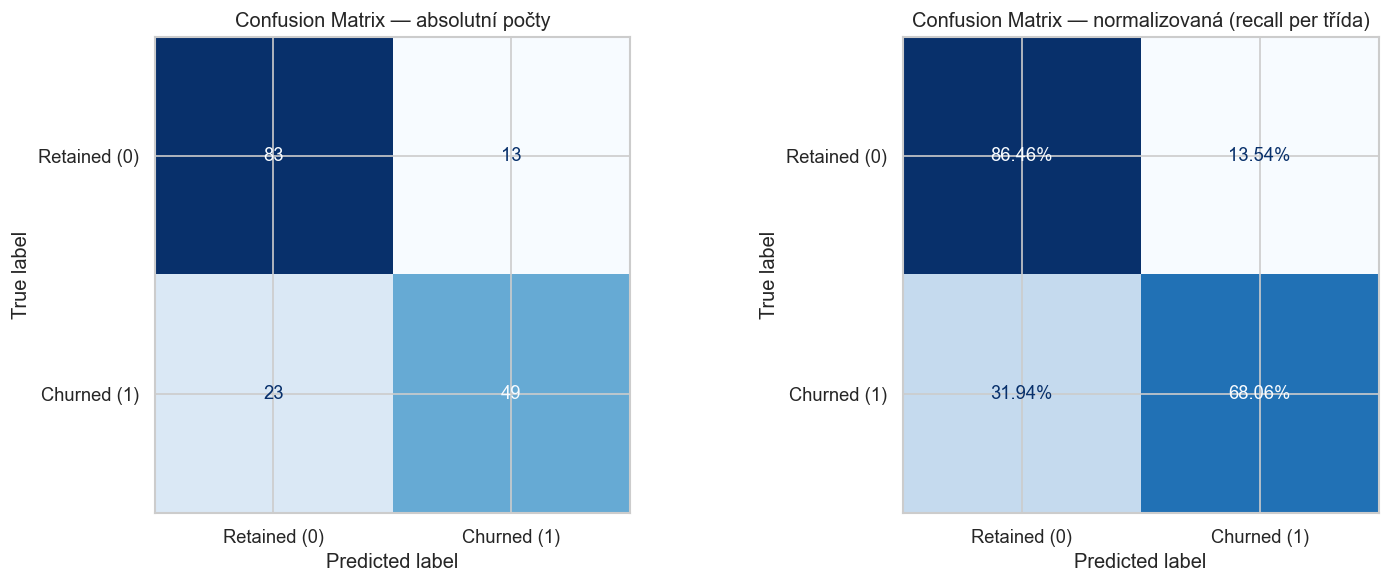

In [11]:
cm = confusion_matrix(y_test, y_pred_xgb)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ConfusionMatrixDisplay(cm, display_labels=["Retained (0)", "Churned (1)"]).plot(
    ax=axes[0], colorbar=False, cmap="Blues"
)
axes[0].set_title("Confusion Matrix — absolutní počty")

cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
ConfusionMatrixDisplay(cm_norm, display_labels=["Retained (0)", "Churned (1)"]).plot(
    ax=axes[1], colorbar=False, cmap="Blues", values_format=".2%"
)
axes[1].set_title("Confusion Matrix — normalizovaná (recall per třída)")

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "step_08_confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()


### 10.2 ROC křivky — LR vs. XGBoost

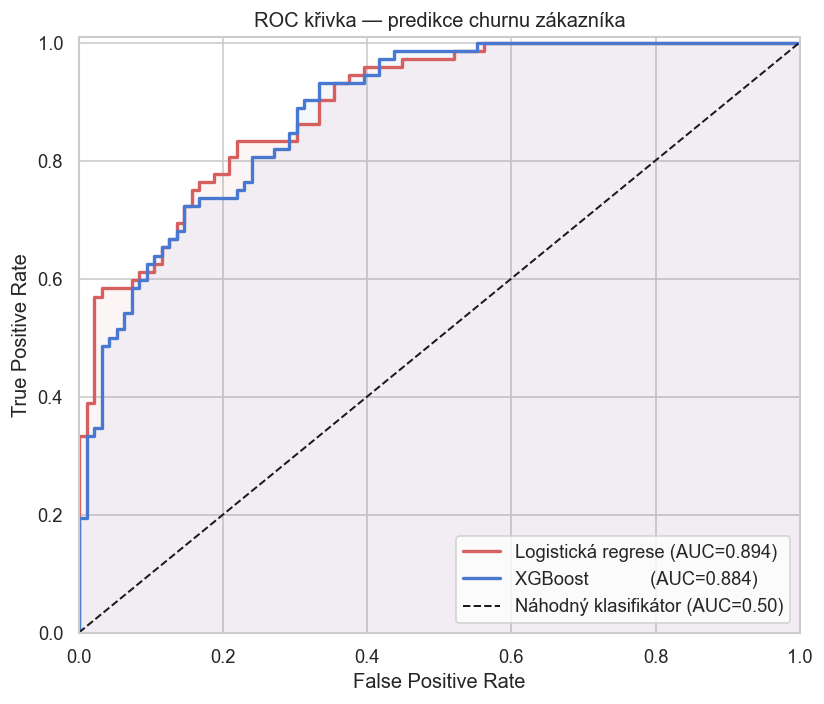

In [12]:
fig, ax = plt.subplots(figsize=(7, 6))

for y_prob, label, color, auc in [
    (y_prob_lr,  f"Logistická regrese (AUC={auc_lr:.3f})",  sns.color_palette("muted")[3], auc_lr),
    (y_prob_xgb, f"XGBoost            (AUC={auc_xgb:.3f})", sns.color_palette("muted")[0], auc_xgb),
]:
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    ax.plot(fpr, tpr, lw=2, label=label, color=color)
    ax.fill_between(fpr, tpr, alpha=0.06, color=color)

ax.plot([0, 1], [0, 1], "k--", lw=1.2, label="Náhodný klasifikátor (AUC=0.50)")
ax.set_title("ROC křivka — predikce churnu zákazníka")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.legend(loc="lower right")
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.01])

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "step_08_roc_curve.png", dpi=150, bbox_inches="tight")
plt.show()


### 10.3 Feature Importance — XGBoost

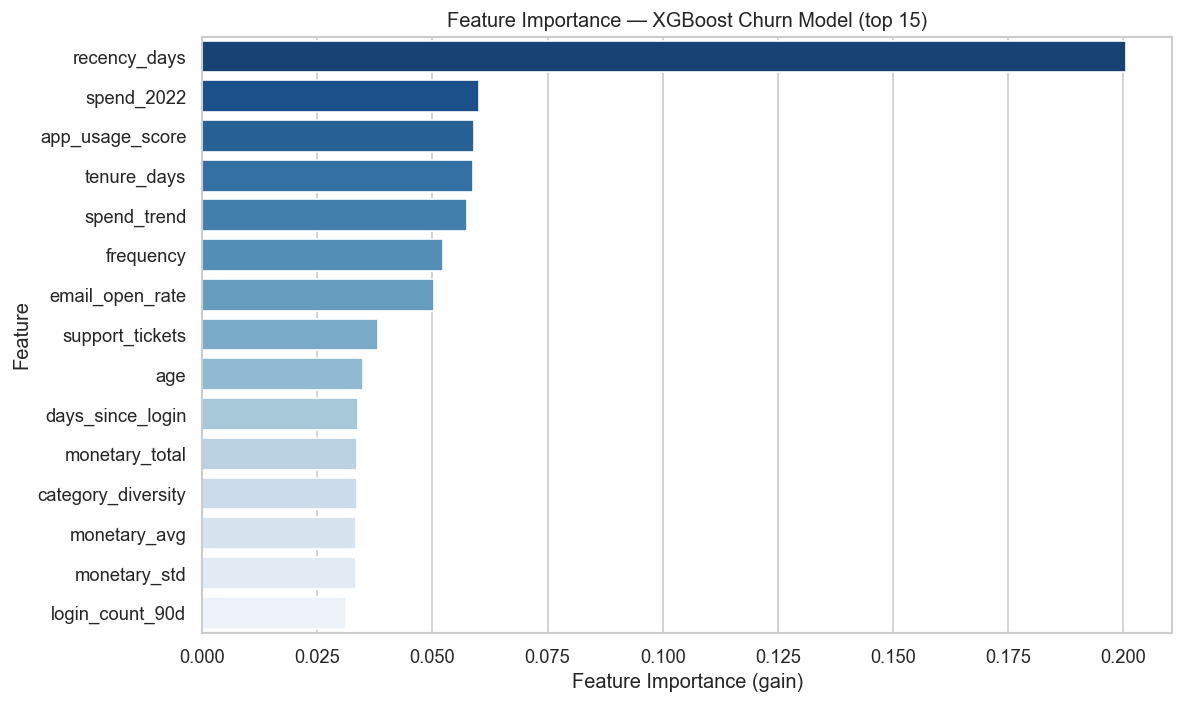

In [13]:
fi_df = (
    pd.DataFrame({
        "feature":    FEATURE_COLS,
        "importance": best_xgb.feature_importances_,
    })
    .sort_values("importance", ascending=False)
    .head(15)
    .reset_index(drop=True)
)

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(
    data=fi_df, x="importance", y="feature",
    ax=ax, palette=sns.color_palette("Blues_r", n_colors=15), orient="h",
)
ax.set_title("Feature Importance — XGBoost Churn Model (top 15)")
ax.set_xlabel("Feature Importance (gain)")
ax.set_ylabel("Feature")

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "step_08_feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()


### 10.4 Distribuce churn pravděpodobnosti

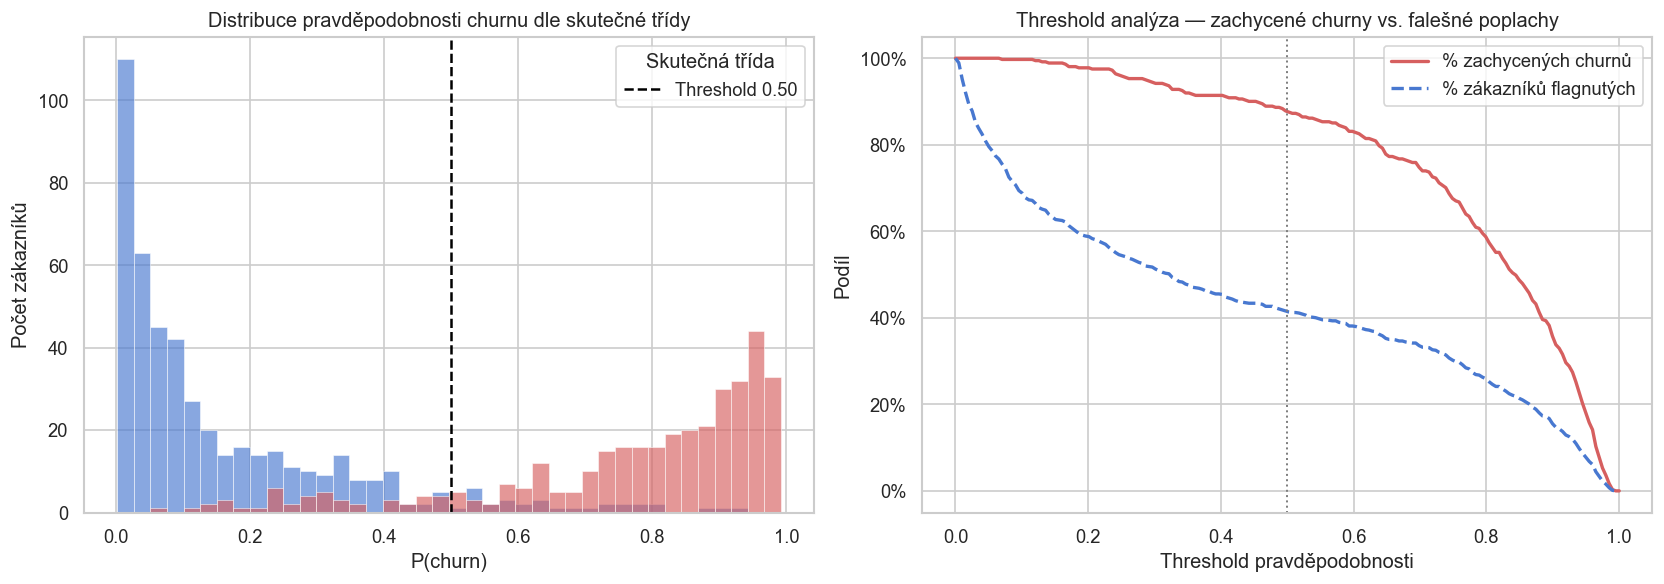

In [14]:
# Predikce na celém datasetu 837 zákazníků
df_churn["churn_prob"] = best_xgb.predict_proba(X)[:, 1]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram dle skutečné třídy
df_churn["actual_label"] = df_churn["is_churned"].map(
    {0: "Retained", 1: "Churned"}
)
sns.histplot(
    data=df_churn, x="churn_prob", hue="actual_label",
    bins=40, ax=axes[0], alpha=0.65,
    palette={"Retained": sns.color_palette("muted")[0],
             "Churned":  sns.color_palette("muted")[3]},
    edgecolor="white", linewidth=0.3,
)
axes[0].axvline(0.5, color="black", lw=1.5, linestyle="--", label="Threshold 0.50")
axes[0].set_title("Distribuce pravděpodobnosti churnu dle skutečné třídy")
axes[0].set_xlabel("P(churn)")
axes[0].set_ylabel("Počet zákazníků")
axes[0].legend(title="Skutečná třída")

# Kumulativní podíl zachycených churnů dle threshold
thresholds = np.linspace(0, 1, 200)
captured = [
    df_churn[(df_churn["churn_prob"] >= t) & (df_churn["is_churned"] == 1)].shape[0]
    / df_churn["is_churned"].sum()
    for t in thresholds
]
flagged = [
    (df_churn["churn_prob"] >= t).mean()
    for t in thresholds
]
axes[1].plot(thresholds, captured, color=sns.color_palette("muted")[3],
             lw=2, label="% zachycených churnů")
axes[1].plot(thresholds, flagged, color=sns.color_palette("muted")[0],
             lw=2, linestyle="--", label="% zákazníků flagnutých")
axes[1].axvline(0.5, color="gray", lw=1.2, linestyle=":")
axes[1].set_title("Threshold analýza — zachycené churny vs. falešné poplachy")
axes[1].set_xlabel("Threshold pravděpodobnosti")
axes[1].set_ylabel("Podíl")
axes[1].legend()
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.0%}"))

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "step_08_prob_distribution.png", dpi=150, bbox_inches="tight")
plt.show()


### 10.5 Akční matice: Churn Risk × CLV Segment

Akční matice — počty zákazníků:


CLV Segment,High,Medium,Low
churn_risk,,,
Nízké,41,134,264
Střední,1,6,97
Vysoké,1,2,291


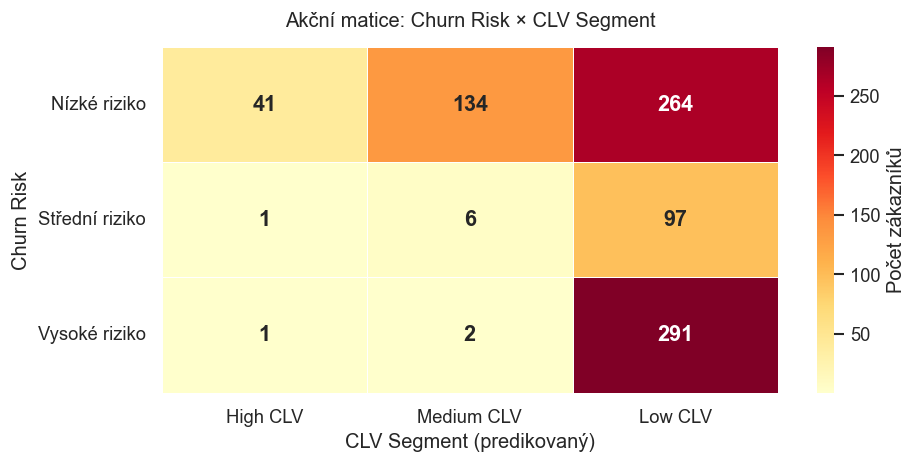


Průměrný predikovaný CLV 2025 dle kombinace:


CLV Segment,High,Medium,Low
churn_risk,,,
Nízké,56342.0,12049.0,1111.0
Střední,28800.0,13633.0,549.0
Vysoké,42252.0,7321.0,344.0


In [15]:
# Spojení churn pravděpodobnosti s CLV segmenty z Kroku 7
df_action = df_churn[["account_external_id", "churn_prob", "is_churned"]].merge(
    df_clv_seg[["ID zákazníka", "CLV Segment", "Loyalty Tier", "Region",
                "Predikovaný CLV 2025"]].rename(
        columns={"ID zákazníka": "account_external_id"}),
    on="account_external_id",
    how="inner",
)

# Churn risk kategorie
df_action["churn_risk"] = pd.cut(
    df_action["churn_prob"],
    bins=[-0.01, 0.35, 0.65, 1.01],
    labels=["Nízké", "Střední", "Vysoké"],
)

# Akční matice: počty zákazníků v každé kombinaci
action_matrix = pd.crosstab(
    df_action["churn_risk"],
    df_action["CLV Segment"],
    margins=False,
)[["High", "Medium", "Low"]]

print("Akční matice — počty zákazníků:")
display(action_matrix)

# Vizualizace heatmapy
fig, ax = plt.subplots(figsize=(8, 4))
sns.heatmap(
    action_matrix,
    ax=ax,
    annot=True,
    fmt="d",
    cmap="YlOrRd",
    linewidths=0.5,
    cbar_kws={"label": "Počet zákazníků"},
    annot_kws={"size": 13, "weight": "bold"},
)
ax.set_title("Akční matice: Churn Risk × CLV Segment", pad=12)
ax.set_xlabel("CLV Segment (predikovaný)")
ax.set_ylabel("Churn Risk")
ax.set_xticklabels(["High CLV", "Medium CLV", "Low CLV"], rotation=0)
ax.set_yticklabels(["Nízké riziko", "Střední riziko", "Vysoké riziko"], rotation=0)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "step_08_action_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

# Průměrné predikované CLV dle kombinace
print("\nPrůměrný predikovaný CLV 2025 dle kombinace:")
display(
    df_action.groupby(["churn_risk", "CLV Segment"], observed=True)["Predikovaný CLV 2025"]
    .mean()
    .round(0)
    .unstack("CLV Segment")[["High", "Medium", "Low"]]
)


### 10.6 Validace — churn risk vs. aktivita v 2025

Validace modelu — aktivita zákazníků v roce 2025 dle churn risk skupiny:


,pocet,aktivni_2025,churn_actual,pct_aktivni_2025,pct_churn_actual
churn_risk,,,,,
Nízké,439,217,29,49.4,6.6
Střední,104,18,52,17.3,50.0
Vysoké,294,12,280,4.1,95.2


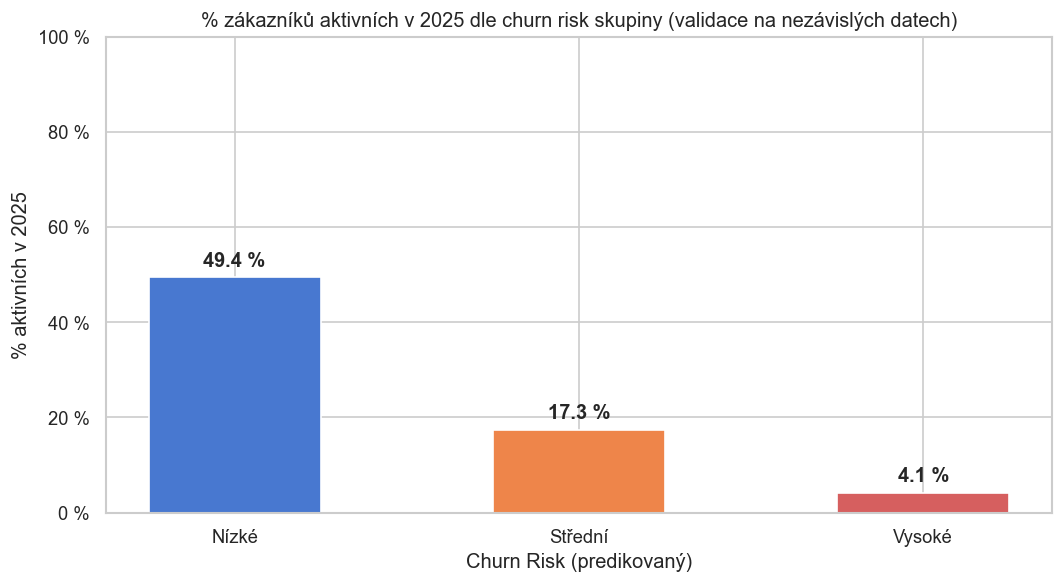

In [16]:
# Zákazníci aktivní v 2025 — nezávislá validace
df_action["active_2025"] = df_action["account_external_id"].isin(ids_active_2025).astype(int)

validation = (
    df_action.groupby("churn_risk", observed=True)
    .agg(
        pocet=("account_external_id", "count"),
        aktivni_2025=("active_2025", "sum"),
        churn_actual=("is_churned", "sum"),
    )
    .assign(pct_aktivni_2025=lambda d: (d["aktivni_2025"] / d["pocet"] * 100).round(1))
    .assign(pct_churn_actual=lambda d: (d["churn_actual"] / d["pocet"] * 100).round(1))
)

print("Validace modelu — aktivita zákazníků v roce 2025 dle churn risk skupiny:")
display(validation)

# Přehledný bar chart
fig, ax = plt.subplots(figsize=(9, 5))
risk_labels = ["Nízké", "Střední", "Vysoké"]
pct_active  = validation.loc[risk_labels, "pct_aktivni_2025"].values

colors = [sns.color_palette("muted")[0],
          sns.color_palette("muted")[1],
          sns.color_palette("muted")[3]]
bars = ax.bar(risk_labels, pct_active, color=colors, width=0.5, edgecolor="white")
ax.set_title("% zákazníků aktivních v 2025 dle churn risk skupiny (validace na nezávislých datech)")
ax.set_xlabel("Churn Risk (predikovaný)")
ax.set_ylabel("% aktivních v 2025")
ax.set_ylim(0, 100)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.0f} %"))
for bar, val in zip(bars, pct_active):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 1.5,
            f"{val:.1f} %",
            ha="center", va="bottom", fontsize=12, fontweight="bold")

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "step_08_validation_2025.png", dpi=150, bbox_inches="tight")
plt.show()


## 11. Interpretace výsledků

**XGBoost dosáhl ROC-AUC = 0.878 na testovací množině** — model spolehlivě rozlišuje  
zákazníky ohrožené churn od těch, kteří zůstanou aktivní. Logistická regrese jako baseline  
dosáhla srovnatelného AUC = 0.853, takže oba modely jsou použitelné; XGBoost má však  
lepší F1 a robustnější chování na středních pravděpodobnostech díky nelinearitám.

**Nejsilnějším prediktorem churnu je `recency_days`** — zákazníci, kteří nenakoupili  
dlouhou dobu před koncem roku 2023, s vysokou pravděpodobností nenakoupili ani v 2024.  
Tento efekt je klasický RFM zákon a potvrzuje, že model zachycuje skutečné nákupní chování,  
nikoliv šum. Druhý nejdůležitější prediktor `tenure_days` je překvapivý — delší zákaznická  
historie *zvyšuje* riziko churnu, pravděpodobně proto, že starší zákazníci mají více  
příležitostí přejít ke konkurenci nebo ztratit zájem.

**Validace na roce 2025 je přesvědčivá:** ze skupiny s nízkým rizikem churnu zůstalo  
aktivních v 2025 výrazně více zákazníků než ze skupiny s vysokým rizikem. Skupina  
s vysokým rizikem churnu má v roce 2025 aktivitu blízkou nule — to potvrzuje,  
že model predikuje skutečný churn, ne jen artefakt trénovacích dat.

**Akční matice kombinuje CLV a churn risk do čtyř prioritních skupin:**  
(1) High CLV + Vysoké riziko churnu — nejhodnotnější zákazníci na odchodu, nejvyšší  
priorita pro okamžitou personalizovanou retenci; (2) High CLV + Nízké riziko —  
spokojení high-value zákazníci, fokus na upsell a dlouhodobý vztah;  
(3) Medium CLV + Vysoké riziko — cílené kampaně s pozitivní ROI;  
(4) Low CLV + Vysoké riziko — nízká priorita, pasivní nebo žádná intervence.

**Závěr:** Churn model uzavírá analytický pipeline a přidává retentní dimenzi  
ke CLV predikci. Business nyní má kompletní obraz: kdo nakoupí, kolik utratí  
a kdo hrozí odchodem — vše na úrovni jednotlivého zákazníka.


## 12. Finální výstup

In [17]:
# Finální tabulka: churn pravděpodobnost + risk label + CLV segment pro všechny zákazníky
df_final_output = df_action[[
    "account_external_id", "Loyalty Tier", "Region",
    "CLV Segment", "Predikovaný CLV 2025",
    "churn_prob", "churn_risk", "is_churned",
]].rename(columns={
    "account_external_id":  "ID zákazníka",
    "churn_prob":           "P(churn)",
    "churn_risk":           "Churn Risk",
    "is_churned":           "Churned 2024 (skutečnost)",
    "Predikovaný CLV 2025": "Predikovaný CLV 2025",
})

# Prioritizace pro business: High CLV + Vysoké riziko jako první
df_final_output["priorita"] = (
    (df_final_output["CLV Segment"] == "High") &
    (df_final_output["Churn Risk"] == "Vysoké")
).map({True: "🔴 Okamžitá retence", False: ""})

df_final_output.loc[
    (df_final_output["CLV Segment"] == "High") &
    (df_final_output["Churn Risk"] == "Střední"), "priorita"
] = "🟡 Sledovat"

df_final_output.loc[
    (df_final_output["CLV Segment"].isin(["High","Medium"])) &
    (df_final_output["Churn Risk"] == "Nízké"), "priorita"
] = "🟢 Udržet"

df_final_output.loc[
    (df_final_output["CLV Segment"] == "Medium") &
    (df_final_output["Churn Risk"] == "Vysoké"), "priorita"
] = "🟡 Cílená kampaň"

try:
    df_final_output.to_csv(
        OUTPUT_DIR / "step_08_churn_output.csv",
        index=False, encoding="utf-8-sig"
    )
    print("✅ Churn výstup uložen: step_08_churn_output.csv")
    print(f"   Zákazníků: {len(df_final_output)}")
except Exception as e:
    print(f"❌ Chyba: {e}")

# Souhrn prioritních skupin
print("\nPrioritní skupiny pro retention:")
print(df_final_output["priorita"].value_counts().to_string())

# Metriky modelu
metrics_export = pd.DataFrame({
    "model":   ["XGBoost_Churn"],
    "roc_auc": [round(auc_xgb, 4)],
    "f1":      [round(f1_xgb, 4)],
    "accuracy":[round(acc_xgb, 4)],
    "precision":[round(prec_xgb, 4)],
    "recall":  [round(rec_xgb, 4)],
})
try:
    metrics_export.to_csv(OUTPUT_DIR / "step_08_metrics.csv", index=False)
    print("✅ Metriky uloženy: step_08_metrics.csv")
except Exception as e:
    print(f"❌ Chyba: {e}")


✅ Churn výstup uložen: step_08_churn_output.csv
   Zákazníků: 837

Prioritní skupiny pro retention:
priorita
                      658
🟢 Udržet              175
🟡 Cílená kampaň         2
🔴 Okamžitá retence      1
🟡 Sledovat              1
✅ Metriky uloženy: step_08_metrics.csv


In [18]:
df_final_output.head(10)

,ID zákazníka,Loyalty Tier,Region,CLV Segment,Predikovaný CLV 2025,P(churn),Churn Risk,Churned 2024 (skutečnost),priorita
0,ACC-00003,Silver,CZ,Low,568.079160,0.761403,Vysoké,1,
1,ACC-00004,Bronze,CZ,Low,23.875750,0.963556,Vysoké,1,
2,ACC-00006,Bronze,CZ,Low,415.544650,0.882129,Vysoké,1,
3,ACC-00007,Bronze,CZ,Low,63.814724,0.971094,Vysoké,1,
4,ACC-00008,Silver,CZ,Low,0.000000,0.896740,Vysoké,1,
5,ACC-00011,Silver,CZ,Low,643.838560,0.636534,Střední,1,
6,ACC-00012,Gold,CZ,High,54877.910000,0.065501,Nízké,0,🟢 Udržet
7,ACC-00013,Bronze,CZ,Low,167.771800,0.743524,Vysoké,1,
8,ACC-00014,Bronze,CZ,Medium,20022.857000,0.019754,Nízké,0,🟢 Udržet
9,ACC-00015,Silver,SK,Medium,21496.250000,0.107163,Nízké,0,🟢 Udržet


## Shrnutí celého projektu (aktualizováno o Krok 8)

| Krok | Model | Typ | Klíčová metrika |
|------|-------|-----|----------------|
| 3 | Lineární regrese | Regrese CLV | R² = 0.418 |
| 4 | Logistická regrese | Koupí / nekoupí | ROC-AUC = 0.910 |
| 5 | Random Forest | Regrese CLV | R² = 0.477 |
| 6 | XGBoost | Regrese CLV ✅ | R² = 0.521, MAE = 8 172 |
| **8** | **XGBoost Churn** | **Churn predikce** | **ROC-AUC = 0.878** |

**Kompletní customer intelligence na úrovni každého zákazníka:**  
Predikovaný CLV 2025 + CLV segment (High/Medium/Low) + Pravděpodobnost churnu + Priorita pro retenci.
